# 3D Hand Keypoints Regression

**Задача**: Регрессия 3D координат (xyz) ключевых точек руки.

## 🎯 Цель: 3D MPJPE ≤ 20 mm

Заполните пропуски (TODO) и добейтесь качества ≤ 20 mm на тесте.

## Подход
- Прямая регрессия xyz координат
- Вход: изображение 224×224
- Выход: 63 значения (21 точка × 3 координаты)


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
from PIL import Image
import os
import json
import zipfile
from tqdm import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(42)
np.random.seed(42)
pl.seed_everything(42)


Seed set to 42


42

## Загрузка датасета FreiHAND


In [2]:
DATA_DIR = "../data/freihand"
EVAL_DIR = os.path.join(DATA_DIR, "evaluation")

if not os.path.exists(EVAL_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    EVAL_ZIP = os.path.join(DATA_DIR, "FreiHAND_pub_v2_eval.zip")
    print("Скачиваем FreiHAND evaluation set...")
    !wget -q --show-progress -O {EVAL_ZIP} https://lmb.informatik.uni-freiburg.de/data/freihand/FreiHAND_pub_v2_eval.zip
    print("Распаковываем архив...")
    with zipfile.ZipFile(EVAL_ZIP, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    os.remove(EVAL_ZIP)
    print("Готово!")
else:
    print(f"Датасет уже существует в {EVAL_DIR}")


Датасет уже существует в ../data/freihand/evaluation


In [3]:
# Загружаем 3D координаты
with open(os.path.join(DATA_DIR, "evaluation_xyz.json"), "r") as f:
    xyz_coordinates = json.load(f)

xyz_coordinates = np.array(xyz_coordinates)  # (N, 21, 3) в метрах

print(f"Количество изображений: {len(xyz_coordinates)}")
print(f"Форма xyz координат: {xyz_coordinates.shape}")
print(f"\nСтатистика координат (в метрах):")
print(f"  X: [{xyz_coordinates[:,:,0].min():.3f}, {xyz_coordinates[:,:,0].max():.3f}]")
print(f"  Y: [{xyz_coordinates[:,:,1].min():.3f}, {xyz_coordinates[:,:,1].max():.3f}]")
print(f"  Z: [{xyz_coordinates[:,:,2].min():.3f}, {xyz_coordinates[:,:,2].max():.3f}]")


Количество изображений: 3960
Форма xyz координат: (3960, 21, 3)

Статистика координат (в метрах):
  X: [-0.118, 0.119]
  Y: [-0.133, 0.107]
  Z: [0.338, 1.022]


## Нормализация 3D координат

Для регрессии нормализуем координаты:
- Делаем координаты **root-relative** (относительно wrist)
- Масштабируем в удобный диапазон


In [4]:
# --- ИСПРАВЛЕННЫЙ БЛОК "Нормализация 3D координат" ---

# 1. Root-relative: вычитаем координаты запястья (точка 0) → (N, 21, 3)
xyz_root_relative = xyz_coordinates - xyz_coordinates[:, 0:1, :]

# 2. Scale-relative: масштабируем на длину от запястья до основания среднего пальца (точка 9)
# Это делает координаты инвариантными к расстоянию до камеры
wrist_to_middle_vec = xyz_root_relative[:, 9, :]  # вектор от wrist к MCP среднего пальца → (N, 3)
wrist_to_middle = np.linalg.norm(wrist_to_middle_vec, axis=1, keepdims=True)  # длина → (N, 1)

# Защита от деления на ноль (на практике почти не бывает, но лучше перестраховаться)
wrist_to_middle = np.clip(wrist_to_middle, a_min=1e-4, a_max=None)

# ВАЖНО: добавляем ещё одну ось, чтобы форма стала (N, 1, 1) — тогда broadcasting с (N, 21, 3) сработает
wrist_to_middle = wrist_to_middle[:, np.newaxis]  # (N, 1) → (N, 1, 1)

# Теперь можно делить: каждая координата (x,y,z) всех 21 точки делится на один и тот же scale
xyz_normalized = xyz_root_relative / wrist_to_middle

# Сохраняем масштаб для восстановления координат в метрах позже
scales = wrist_to_middle.squeeze(axis=(1, 2))  # → (N,) — вектор масштабов (в метрах)

print(f"Scale-relative координаты:")
print(f"  X: [{xyz_normalized[:,:,0].min():.2f}, {xyz_normalized[:,:,0].max():.2f}]")
print(f"  Y: [{xyz_normalized[:,:,1].min():.2f}, {xyz_normalized[:,:,1].max():.2f}]")
print(f"  Z: [{xyz_normalized[:,:,2].min():.2f}, {xyz_normalized[:,:,2].max():.2f}]")
print(f"  Средний масштаб (м): {scales.mean():.4f} ± {scales.std():.4f}")

# Проверка: wrist всегда в (0,0,0) после root-relative?
print("Wrist после нормализации (должно быть ~0):")
print(xyz_normalized[:, 0, :].mean(axis=0))  # → [~0, ~0, ~0]

# Проверка: длина wrist→middle после нормализации = 1?
wrist_to_middle_norm = np.linalg.norm(xyz_normalized[:, 9], axis=1)
print("Длина wrist→middle после нормализации (должно быть =1):")
print(f"mean: {wrist_to_middle_norm.mean():.6f}, std: {wrist_to_middle_norm.std():.6f}")

Scale-relative координаты:
  X: [-1.94, 1.89]
  Y: [-1.91, 1.69]
  Z: [-1.88, 1.86]
  Средний масштаб (м): 0.0915 ± 0.0058
Wrist после нормализации (должно быть ~0):
[0. 0. 0.]
Длина wrist→middle после нормализации (должно быть =1):
mean: 1.000000, std: 0.000000


## Dataset класс


In [5]:
FLIP_IDX = [0,  # wrist
            17, 18, 19, 20,  # thumb ← pinky
            13, 14, 15, 16,  # index ← ring
            9, 10, 11, 12,   # middle — unchanged
            5, 6, 7, 8,      # ring ← index
            1, 2, 3, 4]      # pinky ← thumb

In [6]:
class FreiHand3DDataset(Dataset):
    """Dataset для 3D регрессии ключевых точек руки."""
    
    def __init__(self, data_dir, xyz_normalized, xyz_original, indices=None, img_size=224):
        self.data_dir = data_dir
        self.img_size = img_size
        self.indices = indices if indices is not None else list(range(len(xyz_normalized)))
        self.xyz_normalized = xyz_normalized
        self.xyz_original = xyz_original
        self.scales = scales  # (N, 1)
        
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomApply([
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
            ], p=0.5),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=3)
            ], p=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img_path = os.path.join(self.data_dir, "evaluation", "rgb", f"{real_idx:08d}.jpg")
        image = Image.open(img_path).convert('RGB')
        
        # Получаем исходные координаты
        xyz_norm = self.xyz_normalized[real_idx].copy()
        xyz_orig = self.xyz_original[real_idx].copy()
        scale = self.scales[real_idx]
        
        # # Применяем аугментации вручную (чтобы контролировать flip)
        # if torch.rand(1) < 0.5:  # 50% шанс flip
        #     image = transforms.functional.hflip(image)
        #     # Отражаем X-координату
        #     xyz_norm[:, 0] *= -1
        #     xyz_orig[:, 0] *= -1
        #     # Переставляем точки по симметрии
        #     xyz_norm = xyz_norm[FLIP_IDX]
        #     xyz_orig = xyz_orig[FLIP_IDX]
        
        # # Применяем цветовую аугментацию (если нужно)
        # if torch.rand(1) < 0.5:
        #     image = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)(image)
        # if torch.rand(1) < 0.3:
        #     image = transforms.GaussianBlur(3)(image)
        
        # Финальные преобразования
        image = transforms.ToTensor()(image)
        image = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image)
        
        return (
            image,
            torch.tensor(xyz_norm, dtype=torch.float32).flatten(),
            torch.tensor(xyz_orig, dtype=torch.float32),
            torch.tensor(scale, dtype=torch.float32)
        )


In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32

NUM_SAMPLES = len(xyz_coordinates)
indices = np.random.permutation(NUM_SAMPLES)

train_size = int(0.7 * NUM_SAMPLES)
val_size = int(0.15 * NUM_SAMPLES)

train_indices = indices[:train_size].tolist()
val_indices = indices[train_size:train_size + val_size].tolist()
test_indices = indices[train_size + val_size:].tolist()

train_dataset = FreiHand3DDataset(DATA_DIR, xyz_normalized, xyz_root_relative, train_indices, IMG_SIZE)
val_dataset = FreiHand3DDataset(DATA_DIR, xyz_normalized, xyz_root_relative, val_indices, IMG_SIZE)
test_dataset = FreiHand3DDataset(DATA_DIR, xyz_normalized, xyz_root_relative, test_indices, IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 2772, Val: 594, Test: 594


## Модель: ResNet18 для 3D регрессии


In [8]:
class Keypoint3DRegressor(nn.Module):
    def __init__(self, num_keypoints=21):
        super().__init__()
        
        self.backbone = models.resnet34(weights='IMAGENET1K_V1')
        num_features = 512
        self.backbone.fc = nn.Identity()
        
        self.head = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_keypoints * 3)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

## PyTorch Lightning модуль

Метрика: **3D MPJPE** в миллиметрах


In [9]:
class Keypoint3DModule(pl.LightningModule):
    def __init__(self, num_keypoints=21, learning_rate=1e-4):
        super().__init__()
        self.save_hyperparameters()
        
        self.model = Keypoint3DRegressor(num_keypoints=num_keypoints)
        self.num_keypoints = num_keypoints
        self.learning_rate = learning_rate
    
    def forward(self, x):
        return self.model(x)
    
    def compute_mpjpe_3d(self, pred, target, scales):
        """pred: (B, 63), target: (B, 21, 3), scales: (B,)"""
        pred = pred.view(-1, self.num_keypoints, 3)  # (B, 21, 3)
        # Восстанавливаем в метры: pred * scale
        pred_xyz = pred * scales.view(-1, 1, 1)  # (B, 21, 3)
        distances = torch.sqrt(((pred_xyz - target) ** 2).sum(dim=-1))
        mpjpe = distances.mean() * 1000  # → мм
        return mpjpe

    def training_step(self, batch, batch_idx):
        images, xyz_norm, xyz_orig, scales = batch
        pred = self.forward(images)
        
        # 1. MSE для стабильности
        mse_loss = F.mse_loss(pred, xyz_norm)
        
        # 2. MPJPE loss (в нормализованных координатах — scale-invariant!)
        pred_xyz = pred.view(-1, 21, 3)
        gt_xyz = xyz_norm.view(-1, 21, 3)
        mpjpe_loss = torch.sqrt(((pred_xyz - gt_xyz) ** 2).sum(dim=-1)).mean()
        
        loss = mse_loss + 0.1 * mpjpe_loss  # коэффициент подбирается
        
        mpjpe_mm = self.compute_mpjpe_3d(pred, xyz_orig, scales)
        
        self.log('train_loss', loss)
        self.log('train_mpjpe', mpjpe_mm, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, xyz_norm, xyz_orig, scales = batch
        pred = self.forward(images)
        loss = F.mse_loss(pred, xyz_norm)
        mpjpe = self.compute_mpjpe_3d(pred, xyz_orig, scales)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_mpjpe', mpjpe, on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, xyz_norm, xyz_orig, scales = batch
        pred = self.forward(images)
        loss = F.mse_loss(pred, xyz_norm)
        mpjpe = self.compute_mpjpe_3d(pred, xyz_orig, scales)
        self.log('test_loss', loss)
        self.log('test_mpjpe', mpjpe)
        return loss
    
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=1e-4
        )
        
        # Используем ReduceLROnPlateau по метрике val_mpjpe
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=5,
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_mpjpe",
                "interval": "epoch",
                "frequency": 1,
            }
        }


In [10]:
model = Keypoint3DModule(num_keypoints=21, learning_rate=1e-4)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator='auto',
    devices=1,
    callbacks=[
        ModelCheckpoint(monitor='val_mpjpe', mode='min', save_top_k=1),
        EarlyStopping(monitor='val_mpjpe', mode='min', patience=10)
    ],
    enable_progress_bar=True
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [11]:
trainer.fit(model, train_loader, val_loader)


You are using a CUDA device ('NVIDIA GeForce RTX 4080 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Keypoint3DRegressor │ 21.6 M │ train │     0 │
└───┴───────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 21.6 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 21.6 M                                                                                               
Total estimated model params size (MB): 86                                                                         
Modules in train mode: 123                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

In [12]:
test_results = trainer.test(model, test_loader)
print(f"\nРезультаты на тесте:")
print(f"  3D MPJPE: {test_results[0]['test_mpjpe']:.2f} mm")


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.034531254321336746    │
│        test_mpjpe         │    22.742040634155273     │
└───────────────────────────┴───────────────────────────┘


Результаты на тесте:
  3D MPJPE: 22.74 mm


## Визуализация 3D предсказаний


In [13]:
SKELETON = [
    [0, 1], [1, 2], [2, 3], [3, 4],      # Thumb
    [0, 5], [5, 6], [6, 7], [7, 8],      # Index
    [0, 9], [9, 10], [10, 11], [11, 12], # Middle
    [0, 13], [13, 14], [14, 15], [15, 16], # Ring
    [0, 17], [17, 18], [18, 19], [19, 20]  # Pinky
]

FINGER_COLORS = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1).permute(1, 2, 0).numpy()


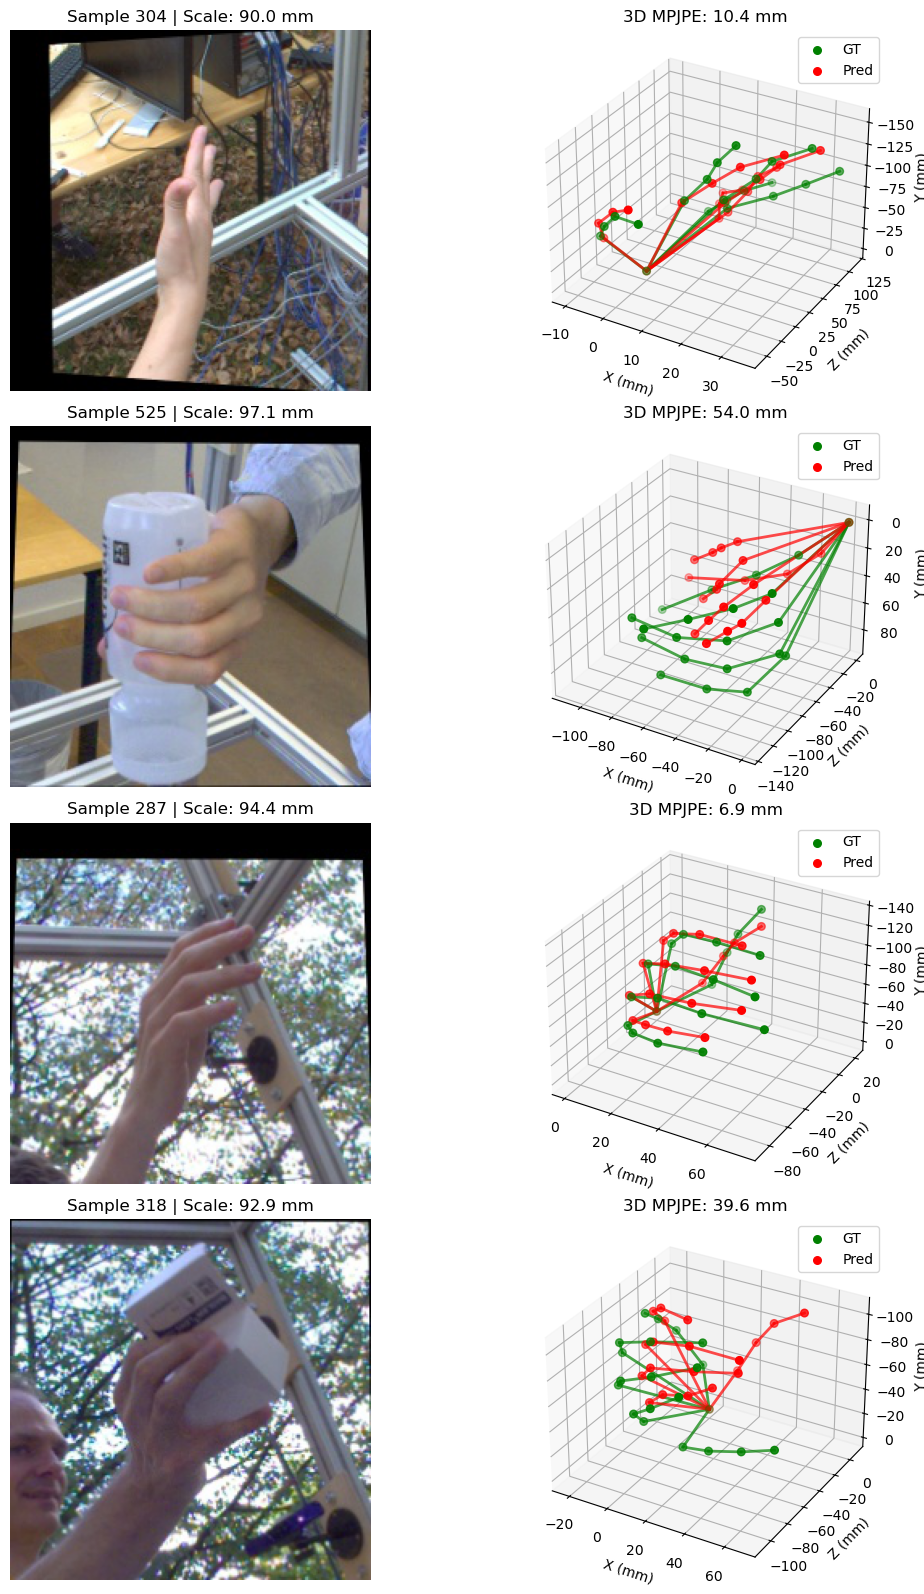

In [14]:
def visualize_3d_predictions(model, dataset, num_samples=4):
    model.eval()
    device = next(model.parameters()).device
    
    fig = plt.figure(figsize=(12, 4*num_samples))
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # ❗ Теперь 4 возвращаемых значения: image, xyz_norm, xyz_orig, scale
            image, xyz_norm, xyz_orig, scale = dataset[idx]
            
            # Предсказание (нормализованные координаты)
            pred = model(image.unsqueeze(0).to(device)).cpu().squeeze()
            pred_xyz_norm = pred.view(21, 3).numpy()  # (21, 3) — нормализованные!
            
            # 🔑 Восстанавливаем в метры: умножаем на scale (как делали в compute_mpjpe_3d)
            pred_xyz_m = pred_xyz_norm * scale.item()  # (21, 3) в метрах
            pred_xyz = pred_xyz_m * 1000  # → в миллиметрах
            
            # GT уже в метрах (root-relative), переводим в мм
            gt_xyz = xyz_orig.numpy() * 1000  # (21, 3) в мм
            
            # Ошибка (в мм)
            error = np.sqrt(((pred_xyz - gt_xyz) ** 2).sum(axis=1)).mean()
            
            # 1. Изображение
            ax1 = fig.add_subplot(num_samples, 2, i*2 + 1)
            ax1.imshow(denormalize_image(image))
            ax1.set_title(f'Sample {idx} | Scale: {scale.item()*1000:.1f} mm')
            ax1.axis('off')
            
            # 2. 3D скелет (GT зелёный, Pred красный)
            ax2 = fig.add_subplot(num_samples, 2, i*2 + 2, projection='3d')
            
            # GT - зелёный
            for edge in SKELETON:
                ax2.plot3D([gt_xyz[edge[0], 0], gt_xyz[edge[1], 0]],
                          [gt_xyz[edge[0], 2], gt_xyz[edge[1], 2]],  # Z → глубина (ось Y в графике)
                          [gt_xyz[edge[0], 1], gt_xyz[edge[1], 1]],  # Y → высота (ось Z в графике)
                          'g-', linewidth=2, alpha=0.7)
            ax2.scatter(gt_xyz[:, 0], gt_xyz[:, 2], gt_xyz[:, 1], c='green', s=30, label='GT')
            
            # Pred - красный
            for edge in SKELETON:
                ax2.plot3D([pred_xyz[edge[0], 0], pred_xyz[edge[1], 0]],
                          [pred_xyz[edge[0], 2], pred_xyz[edge[1], 2]],
                          [pred_xyz[edge[0], 1], pred_xyz[edge[1], 1]],
                          'r-', linewidth=2, alpha=0.7)
            ax2.scatter(pred_xyz[:, 0], pred_xyz[:, 2], pred_xyz[:, 1], c='red', s=30, label='Pred')
            
            ax2.set_xlabel('X (mm)')
            ax2.set_ylabel('Z (mm)')
            ax2.set_zlabel('Y (mm)')
            ax2.set_title(f'3D MPJPE: {error:.1f} mm')
            ax2.legend()
            ax2.invert_zaxis()  # Инвертируем Y (вверх = меньше координата → как в изображении)
    
    plt.tight_layout()
    plt.show()

visualize_3d_predictions(model, test_dataset, num_samples=4)


## Анализ ошибок по точкам


In [16]:
KEYPOINT_NAMES = [
    'Wrist',
    'Thumb_CMC', 'Thumb_MCP', 'Thumb_IP', 'Thumb_Tip',
    'Index_MCP', 'Index_PIP', 'Index_DIP', 'Index_Tip',
    'Middle_MCP', 'Middle_PIP', 'Middle_DIP', 'Middle_Tip',
    'Ring_MCP', 'Ring_PIP', 'Ring_DIP', 'Ring_Tip',
    'Pinky_MCP', 'Pinky_PIP', 'Pinky_DIP', 'Pinky_Tip'
]

def compute_per_keypoint_error(model, dataloader):
    model.eval()
    device = next(model.parameters()).device
    all_errors = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Computing errors"):
            # ❗ Распаковываем ВСЕ 4 элемента
            images, xyz_norm, xyz_orig, scales = batch
            
            images = images.to(device)
            pred = model(images).cpu()  # (B, 63)
            
            # 1. Преобразуем предсказание в (B, 21, 3)
            pred_xyz_norm = pred.view(-1, 21, 3)  # нормализованные координаты
            
            # 2. Восстанавливаем в метры: умножаем на масштаб (как в compute_mpjpe_3d)
            pred_xyz = pred_xyz_norm * scales.view(-1, 1, 1)  # (B, 21, 3) в метрах
            
            # 3. Считаем ошибку в мм
            errors = torch.sqrt(((pred_xyz - xyz_orig) ** 2).sum(dim=-1)) * 1000  # (B, 21)
            all_errors.append(errors)
    
    all_errors = torch.cat(all_errors, dim=0)  # (N, 21)
    return all_errors.mean(dim=0).numpy()  # (21,)


Computing errors: 100%|██████████| 19/19 [00:09<00:00,  1.99it/s]


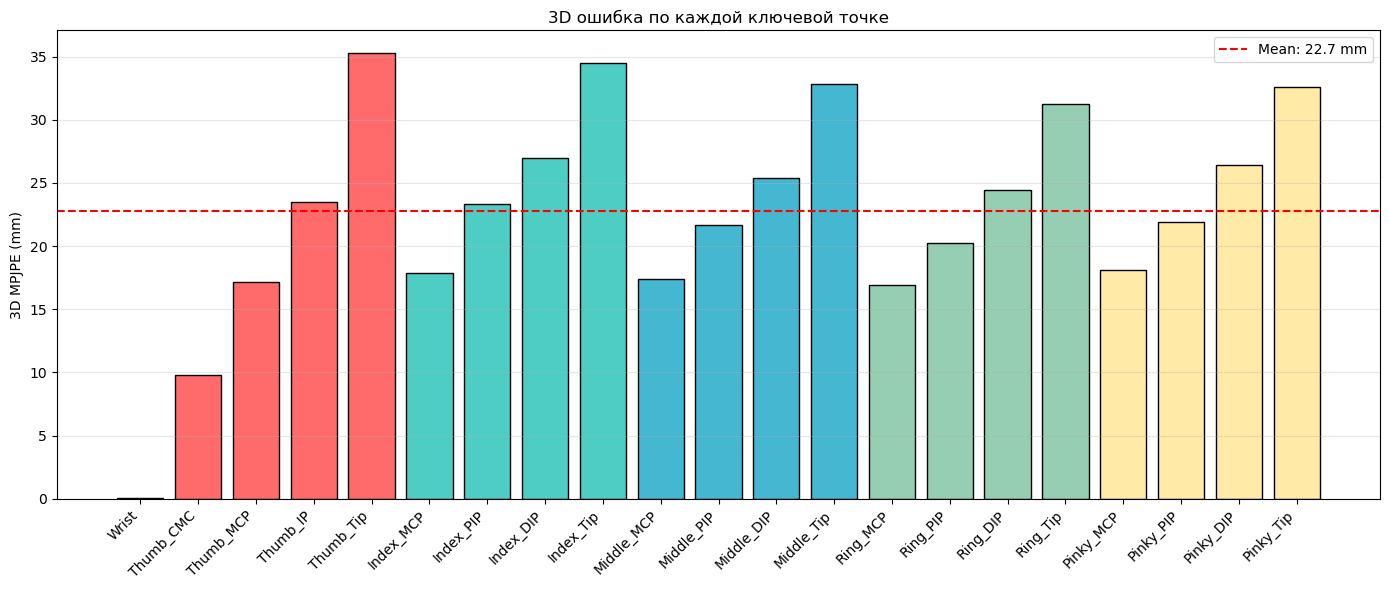

In [17]:
per_kp_errors = compute_per_keypoint_error(model, test_loader)

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#2C3E50'] + ['#FF6B6B']*4 + ['#4ECDC4']*4 + ['#45B7D1']*4 + ['#96CEB4']*4 + ['#FFEAA7']*4

ax.bar(range(21), per_kp_errors, color=colors, edgecolor='black')
ax.set_xticks(range(21))
ax.set_xticklabels(KEYPOINT_NAMES, rotation=45, ha='right')
ax.set_ylabel('3D MPJPE (mm)')
ax.set_title('3D ошибка по каждой ключевой точке')
ax.axhline(y=per_kp_errors.mean(), color='red', linestyle='--', label=f'Mean: {per_kp_errors.mean():.1f} mm')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
